In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/SAMIKSHA/Desktop/projects2/oasis internship/eda on retail sales/retail_sales_dataset.csv")

# Clean column names (BEST PRACTICE)
df.columns = df.columns.str.strip()

# Convert date column
df['Date'] = pd.to_datetime(df['Date'])

# Remove duplicates
df = df.drop_duplicates()

# Check missing values
print(df.isnull().sum())

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [11]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [12]:
print("Mean:", df['Total Amount'].mean())
print("Median:", df['Total Amount'].median())
print("Mode:", df['Total Amount'].mode()[0])
print("Std Dev:", df['Total Amount'].std())

Mean: 456.0
Median: 135.0
Mode: 50
Std Dev: 559.997631555123


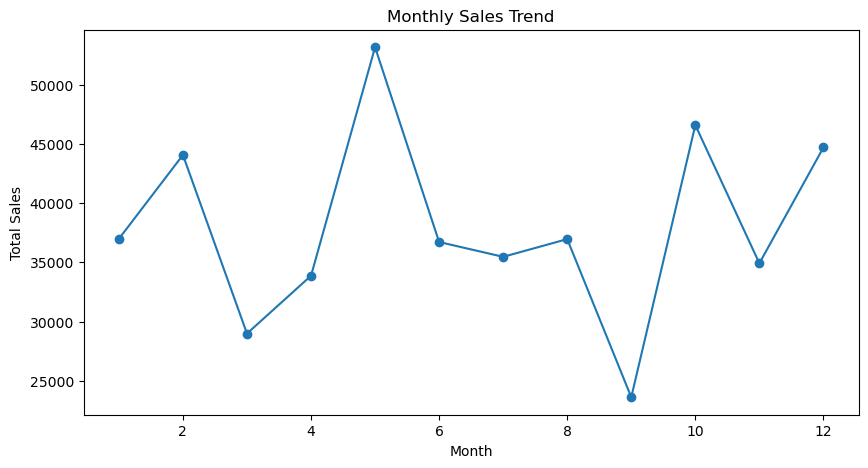

In [13]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

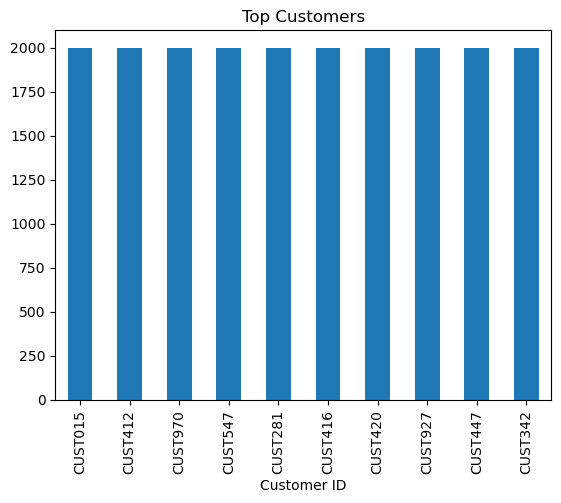

In [14]:
top_customers = df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='bar', title='Top Customers')
plt.show()

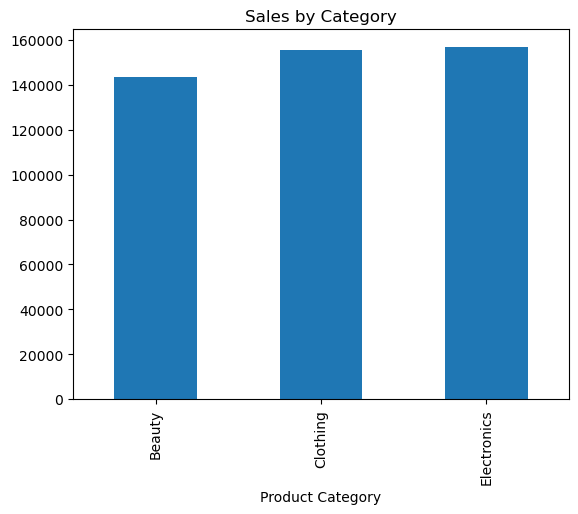

In [15]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()

category_sales.plot(kind='bar', title='Sales by Category')
plt.show()

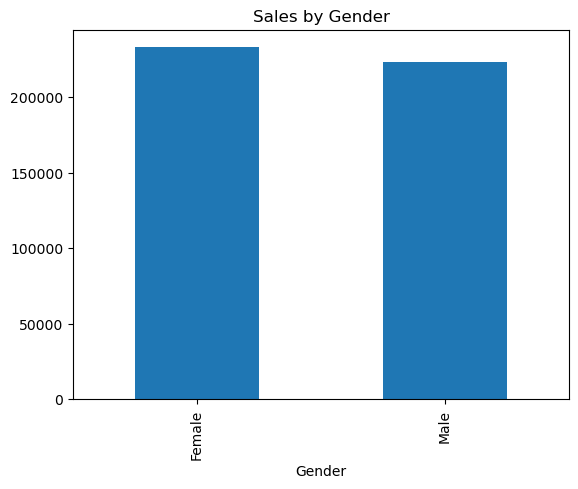

In [16]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

gender_sales.plot(kind='bar', title='Sales by Gender')
plt.show()

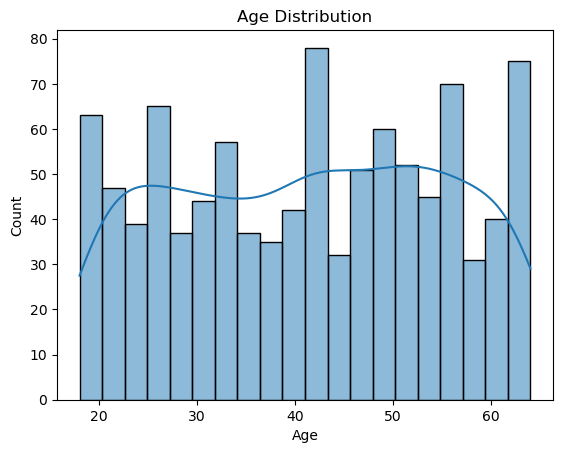

In [17]:
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

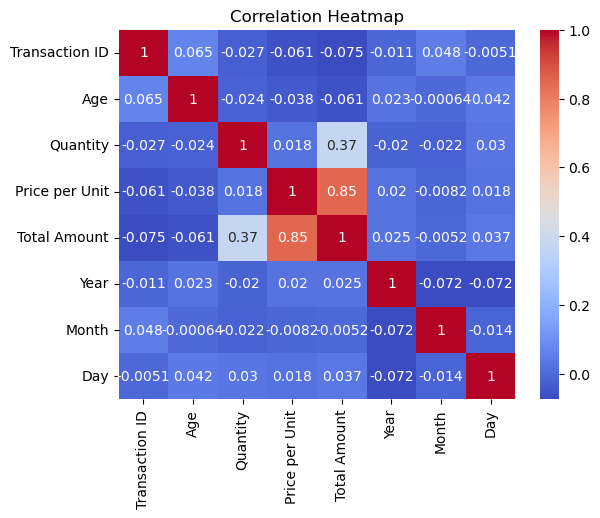

In [18]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

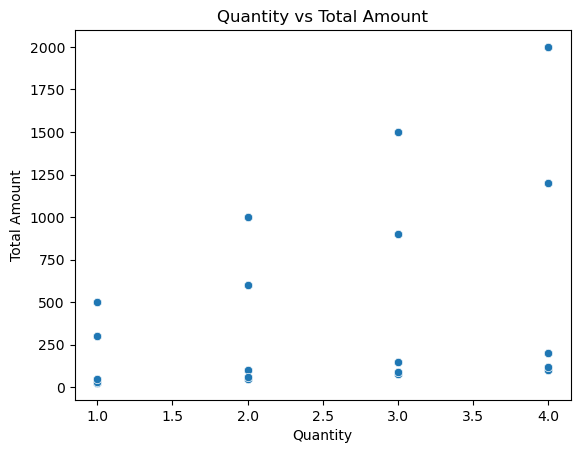

In [19]:
sns.scatterplot(x='Quantity', y='Total Amount', data=df)
plt.title("Quantity vs Total Amount")
plt.show()